# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [4]:
from dataset_NCT00981058 import DatasetNCT00981058

ds_name = 'real_NCT00981058_inject'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_NCT00981058_inject'
SAVE_PATH = f'./pycox_models/{project}/cox_time_pycox_{SEED}'
g_resol = 1
t_resol = 7
split = 'train'
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs()

split = 'test'
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs()

In [5]:
df_test

,subject,duration,g_max_by_time,event_observed,weight,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),...,feat__SMKB_Smoker (all others),feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,is_t_trans
0,b'014-7882',0,1,0.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
1,b'014-7882',1,1,NaN,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
2,b'014-7882',2,1,1.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
3,b'014-7882',3,1,1.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
4,b'014-7882',4,1,1.0,1,-0.347338,0.0,-0.860482,-0.415036,-0.415036,...,1.0,0.0,0.333333,0.905439,1.755901,0.666667,0.0,-0.662496,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81995,b'721-7880',159,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN
81996,b'721-7880',160,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN
81997,b'721-7880',161,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN
81998,b'721-7880',162,5,NaN,1,0.625361,0.0,0.819803,1.545583,1.545583,...,1.0,0.0,0.333333,0.063363,-0.120828,0.333333,0.0,1.273058,0.5,NaN


In [6]:
df_train.head()

,subject,event_observed,duration,g_max_by_time,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),feat__CARDIAC DISORDERS,...,feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,weight,is_t_trans
0,b'001-7882',1,2.0,2.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
1,b'001-7882',1,15.0,4.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
2,b'001-7882',0,126.0,5.0,-0.712101,0.666667,-0.911691,0.110984,0.110984,0.0,...,0.0,0.666667,-1.685565,-0.746404,0.0,0.0,-0.381528,0.25,1,1
3,b'008-7881',1,4.0,1.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1
4,b'008-7881',0,62.0,2.0,-0.347338,0.000000,0.000045,-0.032476,-0.032476,0.0,...,0.0,0.000000,-1.361689,-1.580505,0.0,1.0,-0.100561,0.50,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((270, 53), ((270,), (270,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((540, 53), ((540,), (540,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [64, 64, 64, 64]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))

In [14]:
batch_size = 16

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.7034,	val_loss: 0.6870
1:	[0s / 0s],		train_loss: 0.6305,	val_loss: 0.6253
2:	[0s / 0s],		train_loss: 0.6373,	val_loss: 0.6337
3:	[0s / 0s],		train_loss: 0.5794,	val_loss: 0.5679
4:	[0s / 0s],		train_loss: 0.5692,	val_loss: 0.5524
5:	[0s / 0s],		train_loss: 0.5749,	val_loss: 0.5198
6:	[0s / 0s],		train_loss: 0.5705,	val_loss: 0.4796
7:	[0s / 1s],		train_loss: 0.5188,	val_loss: 0.5163
8:	[0s / 1s],		train_loss: 0.5583,	val_loss: 0.5803
9:	[0s / 1s],		train_loss: 0.5961,	val_loss: 0.5982
10:	[0s / 1s],		train_loss: 0.5349,	val_loss: 0.5491
11:	[0s / 1s],		train_loss: 0.5175,	val_loss: 0.4790
12:	[0s / 1s],		train_loss: 0.5140,	val_loss: 0.4939
13:	[0s / 1s],		train_loss: 0.5111,	val_loss: 0.5026
14:	[0s / 1s],		train_loss: 0.5245,	val_loss: 0.4715
15:	[0s / 1s],		train_loss: 0.5282,	val_loss: 0.5288
16:	[0s / 2s],		train_loss: 0.5177,	val_loss: 0.4754
17:	[0s / 2s],		train_loss: 0.4991,	val_loss: 0.4857
18:	[0s / 2s],		train_loss: 0.5771,	val_loss: 0.5032
19:

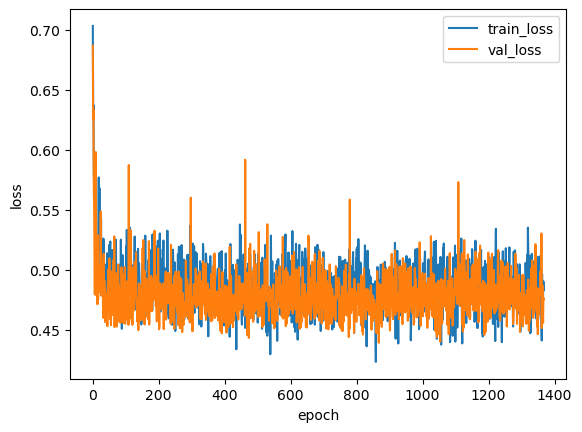

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/pycox/models/cox_time.py:140: RuntimeWarning: overflow encountered in exp
  return np.exp(self.predict((sub, t), batch_size, True, eval_, num_workers=num_workers)).flatten().sum()


-inf

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/pycox/models/cox_time.py:86: RuntimeWarning: overflow encountered in exp
  return np.exp(self.predict((sub, t), batch_size, True, eval_, num_workers=num_workers)).flatten().sum()


In [20]:
x_test.shape

(500, 53)

In [21]:
x_test

array([[ 0.2       , -0.3473384 ,  0.        , ...,  0.        ,
        -0.66249573,  0.        ],
       [ 0.4       , -0.3473384 ,  0.        , ...,  0.        ,
        -0.66249573,  0.        ],
       [ 0.6       , -0.3473384 ,  0.        , ...,  0.        ,
        -0.66249573,  0.        ],
       ...,
       [ 0.6       ,  0.62536067,  0.        , ...,  0.        ,
         1.2730577 ,  0.5       ],
       [ 0.8       ,  0.62536067,  0.        , ...,  0.        ,
         1.2730577 ,  0.5       ],
       [ 1.        ,  0.62536067,  0.        , ...,  0.        ,
         1.2730577 ,  0.5       ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/pycox/models/cox_time.py:118: RuntimeWarning: overflow encountered in exp
  return np.exp(self.predict((input, t), batch_size, True, eval_, num_workers=num_workers)).flatten()


In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
duration,,,,,,,,,,,,,,,,,,,,,
1.0,0.891236,0.962752,0.987565,0.993234,0.993871,5.132063e-01,0.802605,0.930089,0.976397,0.988107,...,7.217795e-01,0.898111,0.965202,0.988396,0.994766,0.798350,0.928454,0.975827,0.988712,0.989773
2.0,0.645046,0.865406,0.953460,0.981792,0.990082,7.842787e-02,0.432067,0.758340,0.912854,0.966433,...,2.854772e-01,0.661456,0.872609,0.956069,0.983918,0.423423,0.753292,0.910837,0.966502,0.982389
3.0,0.556359,0.824219,0.938255,0.976603,0.988354,3.319815e-02,0.325435,0.690694,0.885164,0.956670,...,1.868326e-01,0.575162,0.833300,0.941648,0.978513,0.316745,0.684546,0.882549,0.956502,0.979027
4.0,0.496457,0.793838,0.926440,0.972109,0.986696,1.711986e-02,0.261604,0.642726,0.864407,0.949215,...,1.348514e-01,0.514424,0.800116,0.927817,0.973256,0.253284,0.635903,0.861361,0.948870,0.976444
5.0,0.482900,0.785877,0.923047,0.970811,0.986216,1.472332e-02,0.248916,0.632277,0.859748,0.947525,...,1.234152e-01,0.498090,0.790771,0.923857,0.971741,0.240713,0.625320,0.856609,0.947140,0.975857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170.0,0.011877,0.203927,0.564817,0.811833,0.924046,1.620601e-07,0.003967,0.140394,0.497415,0.776438,...,9.551333e-07,0.006859,0.166120,0.523448,0.790158,0.003566,0.135200,0.490816,0.773382,0.906437
176.0,0.011877,0.203927,0.564817,0.811833,0.924046,1.620601e-07,0.003967,0.140394,0.497415,0.776438,...,9.551333e-07,0.006859,0.166120,0.523448,0.790158,0.003566,0.135200,0.490816,0.773382,0.906437
221.0,0.011877,0.203927,0.564817,0.811833,0.924046,1.620601e-07,0.003967,0.140394,0.497415,0.776438,...,9.551333e-07,0.006859,0.166120,0.523448,0.790158,0.003566,0.135200,0.490816,0.773382,0.906437


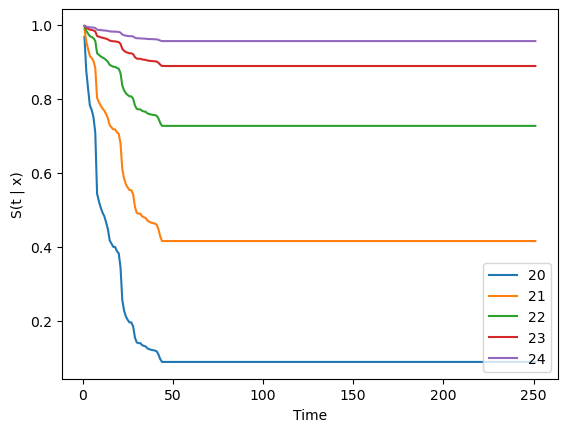

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)